In [2]:

from matplotlib import scale
from matplotlib.ticker import (
    LogLocator,
    ScalarFormatter,
    FormatStrFormatter,
    FuncFormatter,
)
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import json
import os
CWD_DIR = !pwd
DIRECTORY = CWD_DIR[0] + "/ManuscriptFeatureMatrices/"
DATADIR = CWD_DIR[0] + "/ManuscriptFeatureMatrices/"
# DIRECTORY = "./ManuscriptFeatureMatrices/"
MODEL_DIR = CWD_DIR[0] + "/trained_models/"
import json
# test_size = {1:312, 2:406, 3:336, 4:224}

In [ ]:
filename = "/Users/suki/Projects/might/exps/trained_models/TEST_stages_x_type.json"
DATASET = "WiseCondorX.Wise-1.csv"
TEST_TYPES = np.array(["Stomach", "Pancreas", "Esophagus", "Lung", "Liver", "Ovary"])
# read the json as a dataframe
df = pd.read_json(filename)
df = df[df["dataset"] == DATASET]
df["n_estimators"] = df["n_estimators"].astype(int)
df

,test_stage,test_size,dataset,cohort,subset_size,n_estimators,n_jobs,random_state,base_model,max_features,...,s98,s99,accuracy,roc_auc,f1,precision,recall,posterior,y_test,tag
0,1,312,WiseCondorX.Wise-1.csv,None,1660,100,50,43,ObliqueDecisionTreeClassifier,sqrt,...,0.443396,0.250000,0.679487,0.500,0.809160,0.679487,1.0,"[[0.21899441340782103, 0.7810055865921781], [0...","[{'Cancer Status': 1, 'Stage': 1, 'Tumor type'...",test_all_stages_type
1,1,312,WiseCondorX.Wise-1.csv,None,1024,100,50,44,ObliqueDecisionTreeClassifier,sqrt,...,0.358491,0.259434,0.679487,0.500,0.809160,0.679487,1.0,"[[0.318353067814854, 0.681646932185145], [0.34...","[{'Cancer Status': 1, 'Stage': 1, 'Tumor type'...",test_all_stages_type
2,1,312,WiseCondorX.Wise-1.csv,None,512,100,50,45,ObliqueDecisionTreeClassifier,sqrt,...,0.216981,0.165094,0.679487,0.500,0.809160,0.679487,1.0,"[[0.319313779745434, 0.680686220254565], [0.32...","[{'Cancer Status': 1, 'Stage': 1, 'Tumor type'...",test_all_stages_type
3,1,312,WiseCondorX.Wise-1.csv,None,256,100,50,46,ObliqueDecisionTreeClassifier,sqrt,...,0.099057,0.075472,0.679487,0.500,0.809160,0.679487,1.0,"[[0.343941248470012, 0.656058751529987], [0.32...","[{'Cancer Status': 1, 'Stage': 1, 'Tumor type'...",test_all_stages_type
4,1,312,WiseCondorX.Wise-1.csv,None,128,100,50,47,ObliqueDecisionTreeClassifier,sqrt,...,0.018868,0.018868,0.679487,0.500,0.809160,0.679487,1.0,"[[0.329216152019002, 0.6707838479809971], [0.3...","[{'Cancer Status': 1, 'Stage': 1, 'Tumor type'...",test_all_stages_type
5,1,312,WiseCondorX.Wise-1.csv,None,64,100,50,48,ObliqueDecisionTreeClassifier,sqrt,...,0.070755,0.066038,0.679487,0.500,0.809160,0.679487,1.0,"[[0.34866376631448104, 0.6513362336855191], [0...","[{'Cancer Status': 1, 'Stage': 1, 'Tumor type'...",test_all_stages_type
6,2,406,WiseCondorX.Wise-1.csv,None,1566,100,50,49,ObliqueDecisionTreeClassifier,sqrt,...,0.202614,0.156863,0.753695,0.500,0.859551,0.753695,1.0,"[[0.408891488739397, 0.591108511260602], [0.33...","[{'Cancer Status': 1, 'Stage': 2, 'Tumor type'...",test_all_stages_type
7,2,406,WiseCondorX.Wise-1.csv,None,1024,100,50,50,ObliqueDecisionTreeClassifier,sqrt,...,0.339869,0.271242,0.756158,0.505,0.860759,0.755556,1.0,"[[0.41408870667163605, 0.585911293328363], [0....","[{'Cancer Status': 1, 'Stage': 2, 'Tumor type'...",test_all_stages_type
8,2,406,WiseCondorX.Wise-1.csv,None,512,100,50,51,ObliqueDecisionTreeClassifier,sqrt,...,0.160131,0.120915,0.753695,0.500,0.859551,0.753695,1.0,"[[0.366615265998458, 0.633384734001542], [0.33...","[{'Cancer Status': 1, 'Stage': 2, 'Tumor type'...",test_all_stages_type
9,2,406,WiseCondorX.Wise-1.csv,None,256,100,50,52,ObliqueDecisionTreeClassifier,sqrt,...,0.212418,0.183007,0.753695,0.500,0.859551,0.753695,1.0,"[[0.39989759344598, 0.600102406554019], [0.319...","[{'Cancer Status': 1, 'Stage': 2, 'Tumor type'...",test_all_stages_type


In [29]:
subset_sizes = df["subset_size"].unique()
print(subset_sizes)
n_estimators = df["n_estimators"].unique()
print(n_estimators)
test_stages = df["test_stage"].unique()
print(test_stages)
num_test = df.shape[0]   # number of rows
i = 0
row = df.iloc[i]
subset_size_i = row["subset_size"]
print(subset_size_i)
n_estimators_i = row["n_estimators"]
print(n_estimators_i)
test_stage_i = row["test_stage"]
print(test_stage_i)
y_test_i = pd.DataFrame(row["y_test"])
y_test_labels = np.array(y_test_i)[:, 0].astype(int)
y_test_stage = np.array(y_test_i)[:, 1]
y_test_type = np.array(y_test_i)[:, 2]
posterior_i = pd.DataFrame(row["posterior"])
posterior_i
y_pred_i = np.argmax(posterior_i, axis=1)
y_test_stage

[1660 1024  512  256  128   64 1566 1636 1748]
[100]
[1 2 3 4]
1660
100
1


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

(79, 9)
[1660 1024  512  256  128   64 1566 1636 1748 1664 1569 1639 1749 1665]


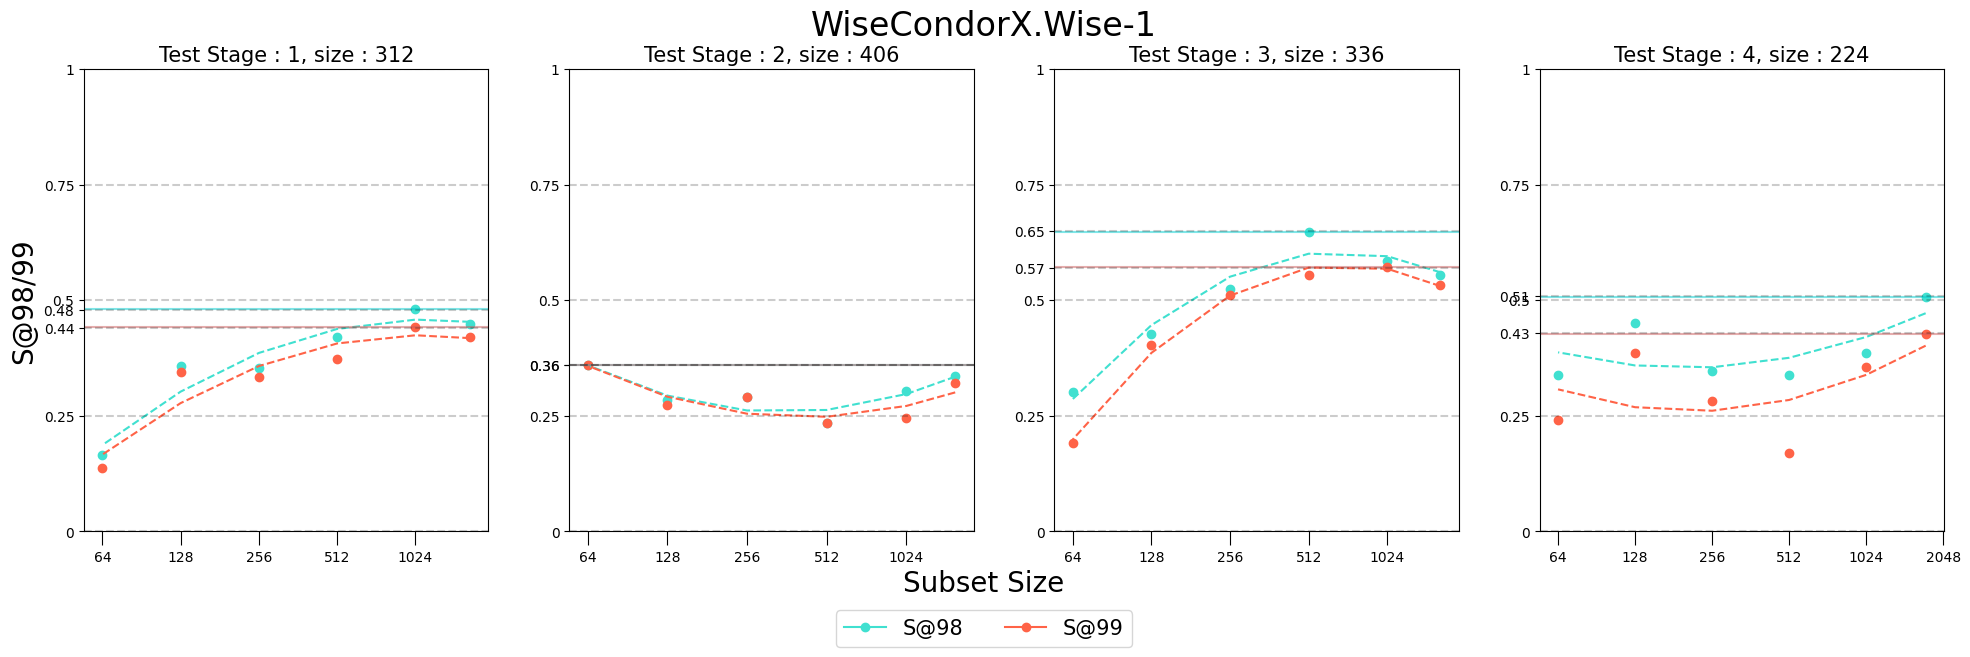

In [ ]:
# load the results
# file_name = "test_stage1_by_cancer_type.csv"
file_name = "test_all_stages_by_cancer_type.json"
# read the json as dataframe
results_df = pd.read_json(MODEL_DIR + file_name)
# results_df = pd.read_csv(MODEL_DIR + file_name)
# covert he n_estimators to int
results_df["n_estimators"] = results_df["n_estimators"].astype(int)
# slice it to where n_estimators is 6000
results_df = results_df[results_df["n_estimators"] == 100_000]
# results_df = results_df[results_df["honest_method"] == 'apply']
# results_df = results_df[results_df["max_features"] == "sqrt"]
# grab just the accuracy, subset_size, fit_time, num_nodes, n_estimator, and base_model
results_df = results_df[
    [
        "test_stage",
        "dataset",
        "subset_size",
        "fit_time",
        "num_nodes",
        "n_estimators",
        "base_model",
        "s98",
        "s99",
    ]
]
models = results_df["base_model"].unique()
print(results_df.shape)
# extact the subset sizes
subset_sizes = results_df["subset_size"].unique()
print(subset_sizes)
# plot the s98 and s99 for each subset size and do it for each test stage
DATASET = "WiseCondorX.Wise-1.csv"
test_stages = results_df["test_stage"].unique()
fig, axs = plt.subplots(1, len(test_stages), figsize=(24, 6))
# Custom formatter to show real numbers
def log2_formatter(x, pos):
    return f"{int(x)}"


for i, test_stage in enumerate(test_stages):
    # splice the results for the test stage
    results_df_stage = results_df[results_df["test_stage"] == test_stage]
    # splice the results for the dataset
    results_df_stage_dataset = results_df_stage[results_df_stage["dataset"] == DATASET]
    subset_sizes = results_df_stage_dataset["subset_size"].unique()
    # plot s98 and s99 with subset size on the x-axis
    s98_values = []
    s99_values = []
    for j, subset_size in enumerate(subset_sizes):
        # get the subset of the results
        df_subset_size = results_df_stage_dataset[
            results_df_stage_dataset["subset_size"] == subset_size
        ]
        # get the s98 and s99
        s98 = df_subset_size["s98"].mean()
        s99 = df_subset_size["s99"].mean()
        s98_values.append((subset_size, s98))
        s99_values.append((subset_size, s99))
        axs[i].plot(subset_size, s98, label=f"S@98", marker="o", color="turquoise")
        axs[i].plot(subset_size, s99, label=f"S@99", marker="o", color="tomato")
    # add regression line
    # Add regression lines
    s98_values = np.array(s98_values)
    # find the max value
    max98 = np.round(np.max(results_df_stage_dataset["s98"]),2)
    s99_values = np.array(s99_values)
    max99 = np.round(np.max(results_df_stage_dataset["s99"]),2)
    # print(s98_values)
    # print(s99_values)

    # Fit a linear regression model to the log-transformed subset sizes
    s98_fit = np.polyfit(np.log2(s98_values[:, 0]), s98_values[:, 1], 2)
    s99_fit = np.polyfit(np.log2(s99_values[:, 0]), s99_values[:, 1], 2)

    # Create the regression lines
    s98_line = np.poly1d(s98_fit)
    s99_line = np.poly1d(s99_fit)

    # Plot the regression lines
    axs[i].plot(
        s98_values[:, 0],
        s98_line(np.log2(s98_values[:, 0])),
        color="turquoise",
        linestyle="--",
        label="S@98",
    )
    axs[i].plot(
        s99_values[:, 0],
        s99_line(np.log2(s99_values[:, 0])),
        color="tomato",
        linestyle="--",
        label="S@99",
    )

    axs[i].tick_params(axis="x", which="major", labelsize=10, length=10)
    # axs[i].tick_params(axis="x", which="minor", labelsize=20, length=8)
    # axs[i].xaxis.set_minor_locator(LogLocator(base=10, numticks=20))
    axs[i].xaxis.set_major_locator(LogLocator(base=2, numticks=5))
    axs[i].set_xscale("log", base=2)
    axs[i].xaxis.set_major_formatter(FuncFormatter(log2_formatter))
    # axs[i].set_xlabel("Subset Size", fontsize=20)
    y_ticks = [0, 0.25, 0.5, 0.75, 1, max98, max99]
    axs[i].set_yticks(y_ticks)
    axs[i].set_yticklabels(y_ticks, fontsize=10)
    # axs[i].set_ylabel("S@98/99", fontsize=20)
    axs[i].axhline(
        y=np.max(results_df_stage_dataset["s98"]),
        color="darkturquoise",
        linestyle="-",
        alpha=0.5,
    )
    # add tick a line for the max s98
    axs[i].axhline(
        y=np.max(results_df_stage_dataset["s99"]),
        color="indianred",
        linestyle="-",
        alpha=0.5,
    )
    for y_tick in y_ticks:
        axs[i].axhline(y=y_tick, color="black", linestyle="--", alpha=0.2)
    # add title
    axs[i].set_title(f"Test Stage : {test_stage}, size : {test_size[test_stage]}", fontsize=15)
axs[0].set_ylabel("S@98/99", fontsize=20)
# Add a global title
fig.suptitle(f"{DATASET}".split(".csv")[0], fontsize=24)
fig.text(
    0.5,
    0.01,
    "Subset Size",
    ha="center",
    fontsize=20,
)
# add legend
fig.legend(
    ["S@98", "S@99"],
    loc="lower center",
    fontsize=15,
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
)

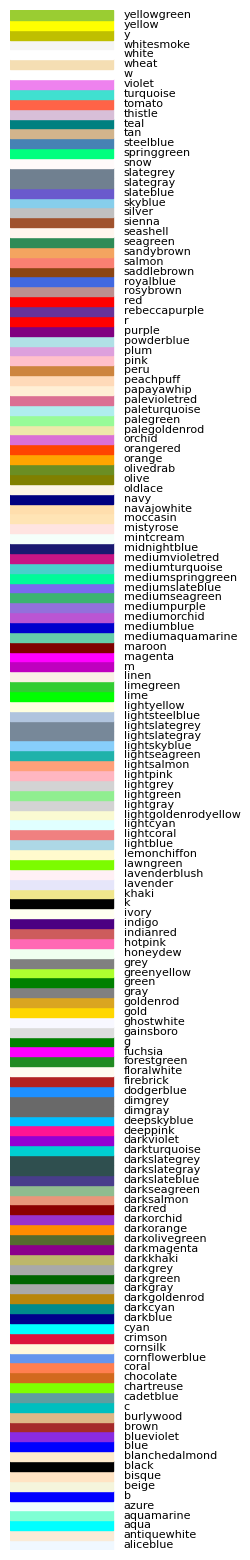

In [44]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Get the list of named colors
colors = dict(mcolors.BASE_COLORS, **mcolors.CSS4_COLORS)

# Sort colors by name
sorted_colors = sorted(colors.items())

# Create a figure to display the colors
fig, ax = plt.subplots(figsize=(2, 20))

# Plot each color as a horizontal bar
for i, (name, color) in enumerate(sorted_colors):
    ax.add_patch(plt.Rectangle((0, i), 10, 1, color=color))
    ax.text(11, i + 0.5, name, va="center", ha="left", fontsize=8)

# Set limits and remove axes
ax.set_xlim(0, 15)
ax.set_ylim(0, len(sorted_colors))
ax.axis("off")

# Show the plot
plt.show()

In [ ]:
# Test on Stage 1 samples and train on all other stages
# DIRECTORY = "../cancer_data/ManuscriptFeatureMatrices/"
import json
import os
CWD_DIR = !pwd
DIRECTORY = CWD_DIR[0] + "/ManuscriptFeatureMatrices/"
DATADIR = CWD_DIR[0] + "/ManuscriptFeatureMatrices/"
# DIRECTORY = "./ManuscriptFeatureMatrices/"
MODEL_DIR = CWD_DIR[0] + "/trained_models/"
N_JOBS = 50
# N_EST = [100, 1000, 10_000,100_000] # 100_000
N_EST = [100_000]
RANDOM_STATE = 42
# TEST_SIZE = 50
PON_TEST_SIZE = 100
REPEATS = 1
STAGE = True
RESULTS_FILE = f"test_all_stages_by_cancer_type.json"
# DATAFILE = "WiseCondorX.Wise-5.csv"
MAX_FEAURES = "sqrt"
TEST_STAGES = np.array(['Stomach', 'Pancreas', 'Esophagus', 'Lung', 'Liver', 'Ovary'])
n= X_train.shape[0]
HONEST_FRACTION = np.round(((n-1)/n)**n,2)
HONEST_PRIOR = "ignore"
HONEST_METHOD = "apply"
# Add tag to the results file
TAG = "test_all_stages"

# collect sample data
sample_list_file = DIRECTORY + "AllSamples.MIGHT.Passed.samples.txt"
sample_list = pd.read_csv(sample_list_file, sep=" ", header=None)
sample_list.columns = ["library", "sample_id", "cohort"]

# get the sample ids for specific cohorts
cohort1 = sample_list[sample_list["cohort"] == "Cohort1"]["sample_id"]
cohort2 = sample_list[sample_list["cohort"] == "Cohort2"]["sample_id"]
PON = sample_list[sample_list["cohort"] == "PanelOfNormals"]["sample_id"]
PON_sample = PON.sample(n=100, random_state=RANDOM_STATE)
# # define a dictionary to store the results
# results = defaultdict(list)
# shuffle the list of data files
# set the seedd
np.random.seed(RANDOM_STATE)
# DATAFILES = list(os.listdir(DATADIR))
# np.random.shuffle(DATAFILES)
# print(DATAFILES)
for i in range(REPEATS):
    if i > 0:
        gc.collect()
    RANDOM_STATE += i
    for n_est in N_EST:
        for DATAFILE in DATAFILES:
        # for DATAFILE in ["WiseCondorX.Wise-5.csv"]:
            if DATAFILE.endswith(".csv"):
                print(f"Datafile: {DATAFILE}")
            else:
                # skip the file
                continue
            print(f"Number of estimators: {n_est}")
            RF = HonestForestClassifier(
                n_estimators=n_est,
                max_samples=1.6,
                max_features=MAX_FEAURES,
                bootstrap=True,
                stratify=True,
                n_jobs=N_JOBS,
                random_state=RANDOM_STATE,
                honest_prior="ignore",
                honest_method="apply",
                tree_estimator=DecisionTreeClassifier(),
            )

            SPORF = HonestForestClassifier(
                n_estimators=n_est,
                max_samples=1.6,
                honest_fraction=HONEST_FRACTION,
                max_features=MAX_FEAURES,
                bootstrap=True,
                stratify=True,
                n_jobs=N_JOBS,
                random_state=RANDOM_STATE,
                honest_prior="ignore",
                honest_method="apply",
                tree_estimator=ObliqueDecisionTreeClassifier(),
            )
            
            # MODELS = [RF, SPORF]
            MODELS = [SPORF]
            # test for each stage separately
            for stage in [1, 2, 3, 4]:
                print(f"Test Stage: {stage}")
                X, y = get_X_y(DATAFILE, root=DIRECTORY, cohort=None, stage=STAGE, tumor_type=True)
                # grab the PON samples 
                X_0 = X[y['Stage']==0]
                y_0 = y[y['Stage']==0]
                # sample 100 samples from X_0 and y_0
                X_0_sample = X_0.sample(n=100, random_state=RANDOM_STATE)
                y_0_sample = y_0.sample(n=100, random_state=RANDOM_STATE)

                # clear cache memory
                del X_0, y_0
                gc.collect()

                # grab the stage 1 samples and use them for testing
                X_test_stage_i, y_test_stage_i = X[(y['Stage']==stage) & (y['Tumor type'].isin(TEST_STAGES))], y[(y['Stage']==stage) & (y['Tumor type'].isin(TEST_STAGES))]

                X_test = pd.concat([X_test_stage_i, X_0_sample], axis=0)
                y_test = pd.concat([y_test_stage_i, y_0_sample], axis=0)
                
                test_size = X_test.shape[0]
                print('test size:', X_test.shape, y_test.shape)
                # get all the samples not in X_test
                X = X[~X.index.isin(X_test.index)]
                y = y[~y.index.isin(y_test.index)]

                # calculate the possible subset sizes for training
                i = 6
                subset_sizes = [X.shape[0]]
                while 2**i < X.shape[0]:
                    subset_sizes.insert(1,2**i)
                    i += 1
                print("subset_sizes: ", subset_sizes[::-1])

                for subset_size in subset_sizes:
                    RANDOM_STATE +=1
                    # get the subset of the data
                    class_feaure = np.array(y)[:,0].astype(int) if not STAGE else np.array(y)[:,1].astype(int)
                    if subset_size == X.shape[0]:
                        X_sub, y_sub = X, y
                    else:
                        X_sub, _, y_sub, _ = train_test_split(X, y, train_size=subset_size, random_state=RANDOM_STATE, stratify=class_feaure)

                    del X, y
                    gc.collect()

                    if y_sub.squeeze().ndim != 1:
                        # set the STAGE parameter to True
                        STAGE = True
                        y_sub_label = np.array(y_sub)[:,0].astype(int)
                        y_sub_stages = np.array(y_sub)[:,1].astype(str)
                
                    # check the class distribution
                    print(f"Subset size: {subset_size}, Class distribution: {np.unique(y_sub_label, return_counts=True)}")

                    # fit the models
                    for est in MODELS:
                        base_model = re.sub(r'\(.*', '', str(est.tree_estimator)) if est.estimator is not None else "NA"
                        kwargs = {}
                        kwargs["test_stage"] = stage
                        kwargs["dataset"] = DATAFILE
                        kwargs["cohort"] = "None"
                        kwargs["subset_size"] = subset_size
                        kwargs["n_estimators"] = n_est
                        kwargs["n_jobs"] = N_JOBS
                        kwargs["random_state"] = RANDOM_STATE
                        kwargs["base_model"] = base_model
                        kwargs["max_features"] = MAX_FEAURES
                        kwargs["honest_fraction"] = HONEST_FRACTION
                        kwargs["honest_prior"] = HONEST_PRIOR
                        kwargs["honest_method"] = HONEST_METHOD
                        # add the model parameters
                        # for key, value in est.get_params().items():
                        #     kwargs[key] = value

                        # start time
                        start_time = time.perf_counter()
                        # obtain tree level posteriors
                        est, tree_proba = build_oob_forest(est, X_sub, y_sub_label)
                        # posterior = np.nanmean(tree_proba, axis=0)#[:, 1]
                        # est.fit(X_sub, y_sub_label)
                        # calculate fitting time
                        end_time = time.perf_counter()
                        time_dif = end_time-start_time
                        kwargs["fit_time"] = time_dif
                        print(f"Subset size: {subset_size}, Model: {base_model}, Time: {time_dif}")
                        # # get the posterior probabilities
                        # forest_proba = np.nanmean(tree_proba, axis=0)
                        # forest_num = np.nanmean(tree_proba, axis=0)
                        # forest_proba_kernel = forest_num/ forest_num.sum(axis=1, keepdims=True)
                        # # print(forest_proba_kernel.shape)
                        # fpr_kernel, tpr_kernel, thresholds_kernel = metrics.roc_curve(y, forest_proba_kernel[:,1], pos_label=1,drop_intermediate = False)
                        # tpr_s_kernel = np.max(tpr_kernel[fpr_kernel<=0.02])
                        
                        # tree_demo = tree_proba.sum(axis=-1, keepdims=True)
                        # tree_proba = tree_proba/ tree_demo
                        # forest_proba = np.nanmean(tree_proba, axis=0)
                        # fpr, tpr, thresholds = metrics.roc_curve(y, forest_proba[:,1], pos_label=1,drop_intermediate = False)
                        # tpr_s = np.max(tpr[fpr<=0.02])

                        # tree_depths = [estimator.tree_.max_depth for estimator in est.estimators_]
                        # tree_num_nodes = [estimator.tree_.node_count for estimator in est.estimators_]

                        posterior = est.predict_proba(X_test)
                        # get the metrics and log the results
                        y_pred = np.argmax(posterior, axis=1)
                        # count the number of nodes
                        kwargs["num_nodes"] = node_count(est, forest=True)

                        del est
                        # clear cache memory
                        gc.collect()

                        y_test_label = np.array(y_test)[:,0].astype(int) if STAGE else y_test
                        y_test_stage = np.array(y_test)[:,1] if STAGE else None
                        # y_test_type = np.array(y_test)[:,2] if len(y_test.shape)>2 else None
                        if STAGE:
                            # calculate the metric for each stage
                            # subset the Normal samples
                            y_test_0 = y_test_label[y_test_label == 0]
                            y_pred_0 = y_pred[y_test_label == 0]
                            posterior_0 = posterior[y_test_label == 0]
                            # for stage in [1]:
                            #     idx = y_test_stage == stage
                            #     # subset the samples for the stage 
                            #     y_test_label_stage = y_test_label[idx] if len(y_test_label[idx]) > 0 else []
                            #     # subset the predictions for the stage
                            #     y_pred_stage = y_pred[idx] if len(y_pred[idx]) > 0 else []
                            #     # subset the posterior for the stage
                            #     posterior_stage = posterior[idx] if len(posterior[idx]) > 0 else []
                            #     # concatenate the y_test_0 and y_test_label_stage
                            #     y_test_label_stage_ = np.concatenate([y_test_0, y_test_label_stage])
                            #     posterior_stage_ = np.concatenate([posterior_0, posterior_stage])
                            #     s98_stage = Calculate_SA(np.array(y_test_label_stage_), np.array(posterior_stage_), max_fpr=0.02)
                            #     print(f"Subset size: {subset_size}, Model: {base_model}, Stage: {stage}, s98: {s98_stage}")
                            #     # store the results for each stage
                            #     kwargs[f"s98_{stage}"] = s98_stage
                        kwargs["s98"] = Calculate_SA(np.array(y_test_label), np.array(posterior), max_fpr=0.02)
                        kwargs["s99"] = Calculate_SA(np.array(y_test_label), np.array(posterior), max_fpr=0.01)
                        kwargs["accuracy"] = accuracy_score(y_test_label, y_pred)
                        kwargs["roc_auc"] = roc_auc_score(y_test_label, y_pred)
                        kwargs["f1"] = f1_score(y_test_label, y_pred)
                        kwargs["precision"] = precision_score(y_test_label, y_pred)
                        kwargs["recall"] = recall_score(y_test_label, y_pred)

                        kwargs["tag"] = TAG
                        # save the results
                        # Define the file path
                        file_path = os.path.join(MODEL_DIR, RESULTS_FILE)
                        # Check if the file exists
                        # Check if the file exists
                        if RESULTS_FILE not in os.listdir(MODEL_DIR):
                            # Save the kwargs as JSON
                            with open(file_path, 'w') as json_file:
                                json.dump([kwargs], json_file, indent=4)  # Save as a list containing the first entry
                        else:
                            # Append the results to the file
                            with open(file_path, 'r+') as json_file:
                                try:
                                    data = json.load(json_file)
                                except json.JSONDecodeError:
                                    data = []  # Initialize with an empty list if the file is empty or invalid
                                data.append(kwargs)
                                json_file.seek(0)
                                json.dump(data, json_file, indent=4)
                        gc.collect()

                    # replace the X, y with the subset
                    X, y = X_sub, y_sub
            # save the model
            # model_name = f"{base_model}_{subset_size}_samples_{N_EST}_n_est.pkl"
            # with open(MODEL_DIR + model_name, "wb", ) as f:
            #     pickle.dump(est, f)
            # print(f"Model saved: {model_name}"
